# Deseq2 

In [1]:
library(DESeq2)
library(tidyverse)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loading required package: SummarizedExperiment

Loading required package: M

Global variables!

In [2]:
padjThreshold <- 0.001
l2fcThreshold <- 1.5

Matrices and Coldata files

In [3]:
gfp_mtx <- list.files("matrices_unionMockAuxResc_25/matrices_1v1/GFP", full.names=T)
gfp_spl <- list.files("matrices_unionMockAuxResc_25/matrices_1v1/GFP", full.names=F)
gfp_cld <- list.files("matrices_unionMockAuxResc_25/coldata_1v1/GFP", full.names = T)

k27_mtx <- list.files("matrices_unionMockAuxResc_25/matrices_1v1/K27", full.names=T)
k27_spl <- list.files("matrices_unionMockAuxResc_25/matrices_1v1/K27", full.names=F)
k27_cld <- list.files("matrices_unionMockAuxResc_25/coldata_1v1/K27", full.names = T)

ub_mtx <- list.files("matrices_unionMockAuxResc_25/matrices_1v1/UB", full.names=T)
ub_spl <- list.files("matrices_unionMockAuxResc_25/matrices_1v1/UB", full.names=F)
ub_cld <- list.files("matrices_unionMockAuxResc_25/coldata_1v1/UB", full.names = T)

check file list

In [4]:
gfp_mtx
gfp_spl
gfp_cld

k27_mtx
k27_spl
k27_cld

ub_mtx
ub_spl
ub_cld

[1] "matrices_unionMockAuxResc_25/matrices_1v1/GFP/GFP_raw_counts_mockVaux.csv"  
[2] "matrices_unionMockAuxResc_25/matrices_1v1/GFP/GFP_raw_counts_rescueVaux.csv"

[1] "GFP_raw_counts_mockVaux.csv"   "GFP_raw_counts_rescueVaux.csv"

[1] "matrices_unionMockAuxResc_25/coldata_1v1/GFP/GFP_metadata_mockVaux.csv"  
[2] "matrices_unionMockAuxResc_25/coldata_1v1/GFP/GFP_metadata_rescueVaux.csv"

[1] "matrices_unionMockAuxResc_25/matrices_1v1/K27/K27_raw_counts_mockVaux.csv"  
[2] "matrices_unionMockAuxResc_25/matrices_1v1/K27/K27_raw_counts_rescueVaux.csv"

[1] "K27_raw_counts_mockVaux.csv"   "K27_raw_counts_rescueVaux.csv"

[1] "matrices_unionMockAuxResc_25/coldata_1v1/K27/K27_metadata_mockVaux.csv"  
[2] "matrices_unionMockAuxResc_25/coldata_1v1/K27/K27_metadata_rescueVaux.csv"

[1] "matrices_unionMockAuxResc_25/matrices_1v1/UB/UB_raw_counts_mockVaux.csv"  
[2] "matrices_unionMockAuxResc_25/matrices_1v1/UB/UB_raw_counts_rescueVaux.csv"

[1] "UB_raw_counts_mockVaux.csv"   "UB_raw_counts_rescueVaux.csv"

[1] "matrices_unionMockAuxResc_25/coldata_1v1/UB/UB_metadata_mockVaux.csv"  
[2] "matrices_unionMockAuxResc_25/coldata_1v1/UB/UB_metadata_rescueVaux.csv"

ad hoc deseq wrapper

In [5]:
mydeseq <- function(cMatrices,cMetadata, cNames, cPadjT, cL2fc, cMinCountSum = 4, cMalim = c(-10,10)){

    for (i in 1:length(cMatrices)){
        # Import files
        mx <- as.matrix(read.csv(cMatrices[i], row.names = 1))
        cd <- read.csv(cMetadata[i], row.names = 1)
        cd$condition <- factor(cd$condition)
        
        # include this to prevent errors due incorrect order of the tables
        if (all(rownames(cd)==colnames(mx))) {

            boxplot(log(mx+1), 
                    main = paste(cNames [i], "counts after filtering, threshold =",cMinCountSum),
                    ylab = "log(counts+1)",
                    xlab = "samples",
                    col = c("red","red","blue","blue")#,
                    #names = str_remove(colnames(mx), ".bam") |> str_remove("rep") #|> str_remove("^[a-z0-9]+_")
                   )
            
            #DESeq object init
            dds <- DESeqDataSetFromMatrix (countData = mx,
                                           colData = cd,
                                           design = ~ condition
                                           )
            
            #DESeq statistical tests
            dds <- DESeq(dds)
            print(sizeFactors(dds))
            deseqResults <- results(dds)
            
            # MA plot
            plotMA(deseqResults, ylim=cMalim, alpha = cPadjT)
            abline(h = cL2fc, col = "red")
            abline(h = -cL2fc, col = "red")
            
            deseqResults$V1 <- rownames(deseqResults)
            
            deseqResults <- as.data.frame(deseqResults)
            deseqResults <- deseqResults |> dplyr::mutate(Significative = dplyr::case_when(
                (abs(log2FoldChange) > cL2fc & padj < cPadjT) ~ TRUE,
                #deseqResults$padj < cPadjT & deseqResults$log2FoldChange > cL2fc
                .default = FALSE))
            
             # Volcano plot
            print(ggplot(deseqResults ,aes(x= log2FoldChange, y = -log(padj), color = Significative)) + geom_point())
            
            dds <- estimateSizeFactors(dds)
            #print(sizeFactors(dds))
            normalizedCounts <- counts(dds, normalized=TRUE) |> as.data.frame()
            colnames(normalizedCounts) <- colnames(normalizedCounts) |> str_remove("\\.bam") |> toupper()
            normalizedCounts$V1 <- rownames(normalizedCounts)
            
            # add change directionality
            
            deseqResults <- deseqResults |> 
                dplyr::mutate(directionality = dplyr::case_when(
                    (log2FoldChange > 0 & Significative == TRUE) ~ "UP",
                    (log2FoldChange < 0 & Significative == TRUE) ~ "DOWN",
                    .default = "NONE"
                )
                             )
            
           
            
            # Write tables
            write.csv(deseqResults, paste0("./deseq2_mockAuxResc_results_36/",cNames[i],"_deseq_results.csv"), quote = F, row.names = F)
            write.csv(normalizedCounts, paste0("./deseq2_mockAuxResc_results_36/",cNames[i],"_norm_counts.csv"), quote = F, row.names = F)
            
            # summary of results
            summary(deseqResults)
            print(paste("Significative increased signal:", sum(deseqResults$padj < cPadjT & deseqResults$log2FoldChange > cL2fc ,na.rm = TRUE)))
            print(paste("Significative decreased signal:",sum(deseqResults$padj < cPadjT & deseqResults$log2FoldChange < -cL2fc ,na.rm = TRUE)))
            print(paste0("log2(FoldChange) threshold: +/-",cL2fc))
            print(paste0("Adjusted P-value threshold: ",cPadjT))
            
        } else { 
            print("matrix colnames doesn't match rownames of metadata, must be ordered equally")
            print("metadata rownames:")
            print(rownames(cd))
            print("matrix colnames:")
            print(colnames(mx))
        }
    }
}

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



Auxin_GFP.1 Auxin_GFP.2  Mock_GFP.1  Mock_GFP.2 
  0.5539478   0.4515807   2.0787066   2.1781030 


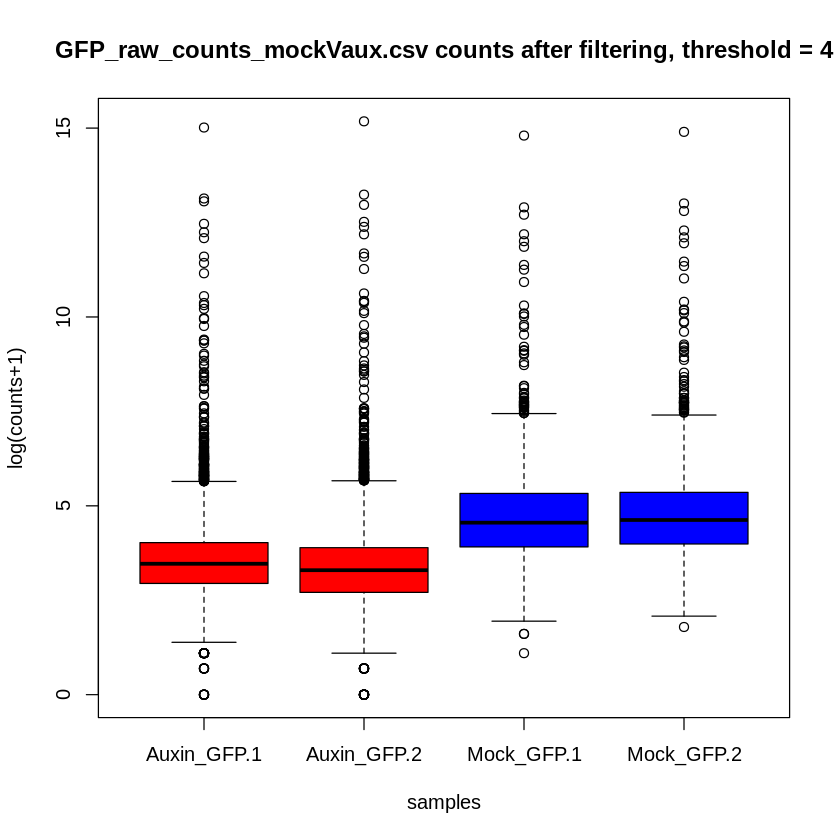

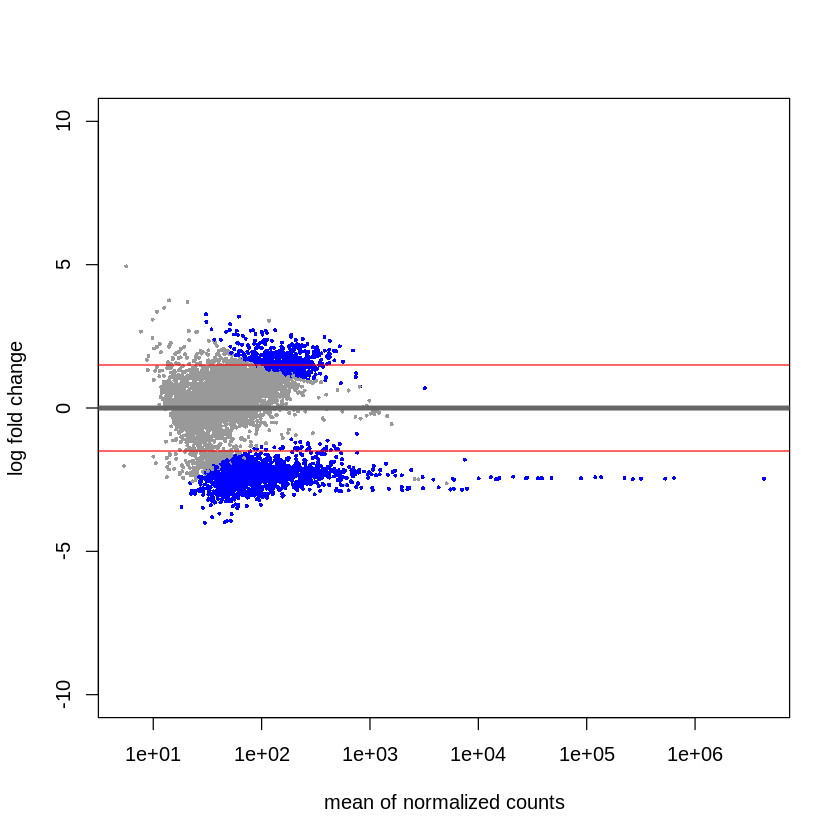

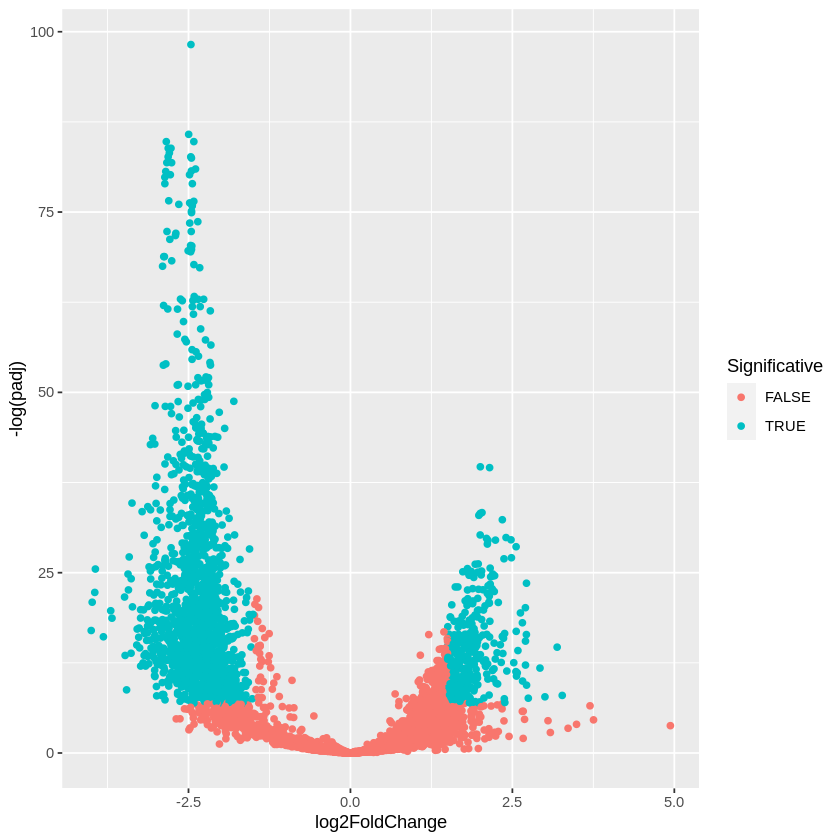

[1] "Significative increased signal: 357"
[1] "Significative decreased signal: 1623"
[1] "log2(FoldChange) threshold: +/-1.5"
[1] "Adjusted P-value threshold: 0.001"


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



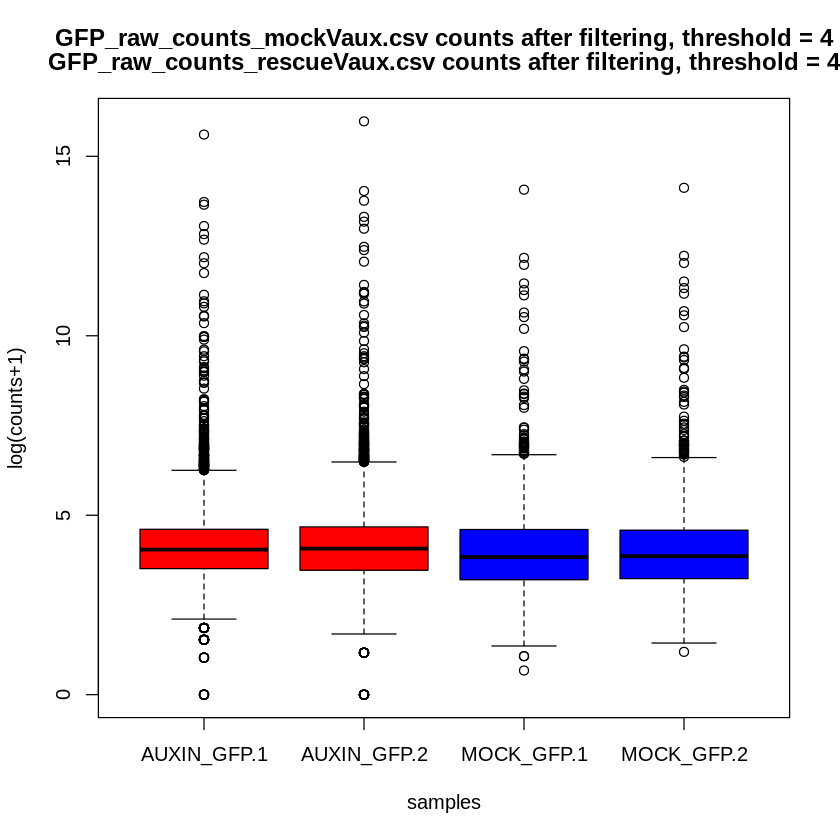

       Auxin_GFP.1        Auxin_GFP.2 SimpleRescue_GFP.1 SimpleRescue_GFP.2 
         0.8601543          0.7340710          1.1753969          1.4402398 


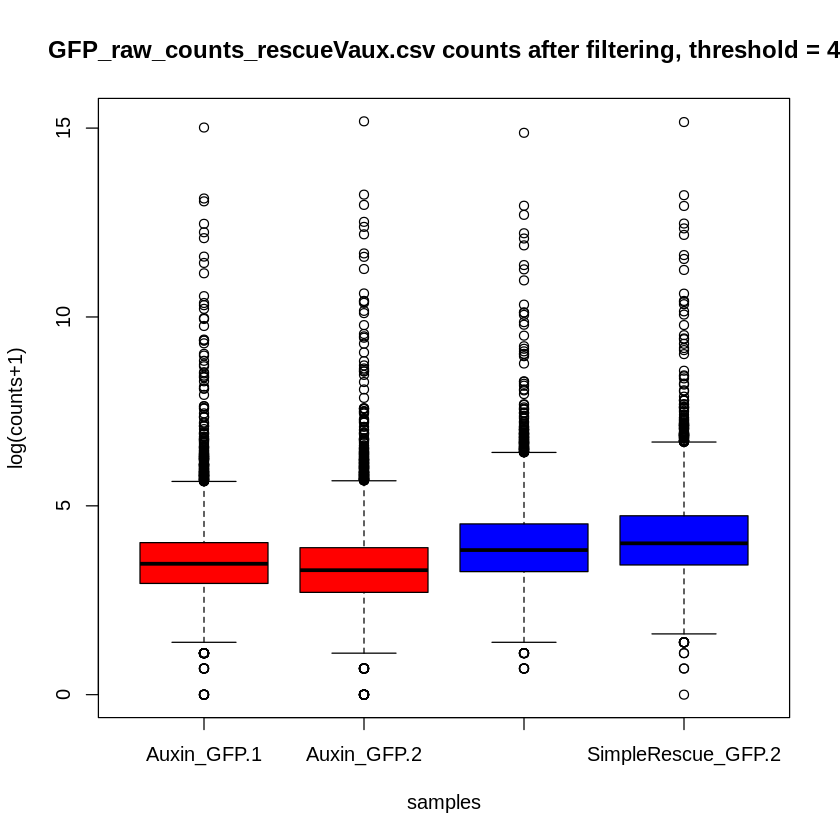

Warning message:
“Removed 1615 rows containing missing values (`geom_point()`).”


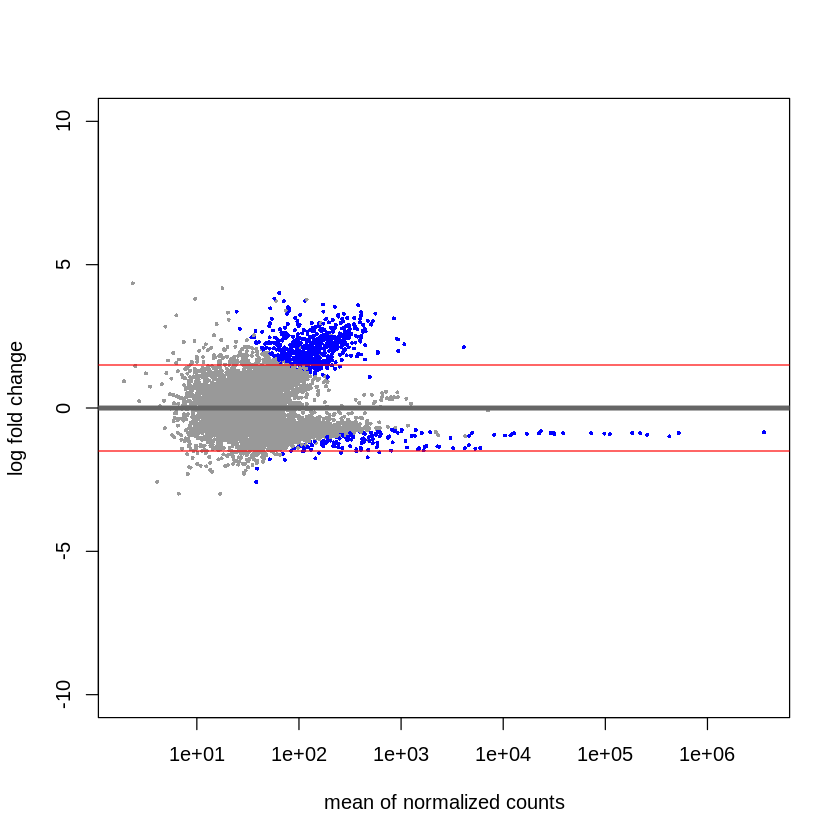

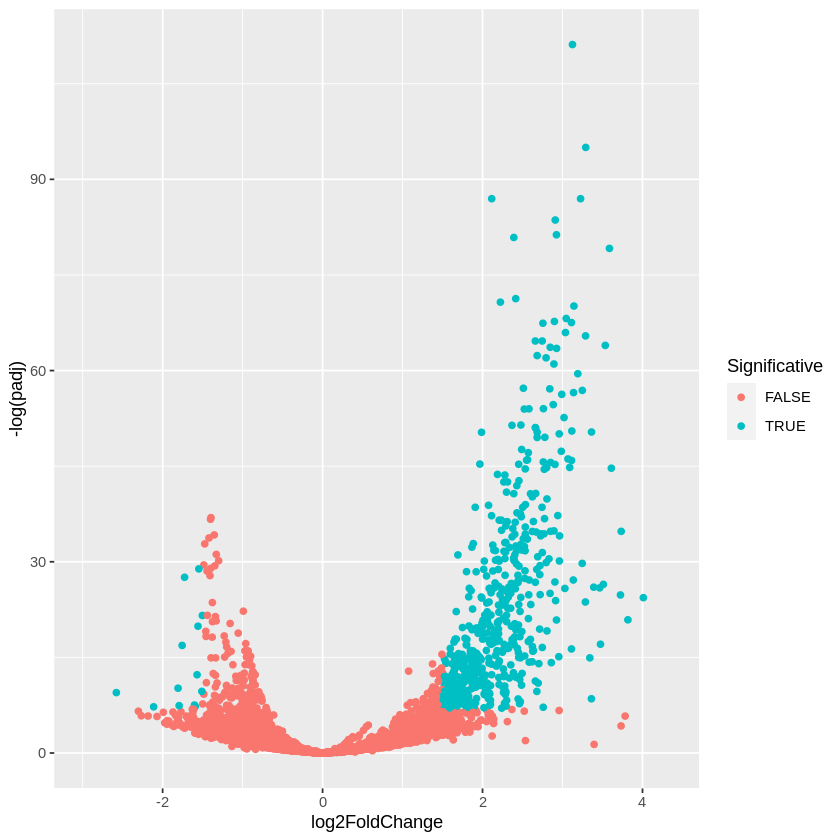

[1] "Significative increased signal: 539"
[1] "Significative decreased signal: 13"
[1] "log2(FoldChange) threshold: +/-1.5"
[1] "Adjusted P-value threshold: 0.001"


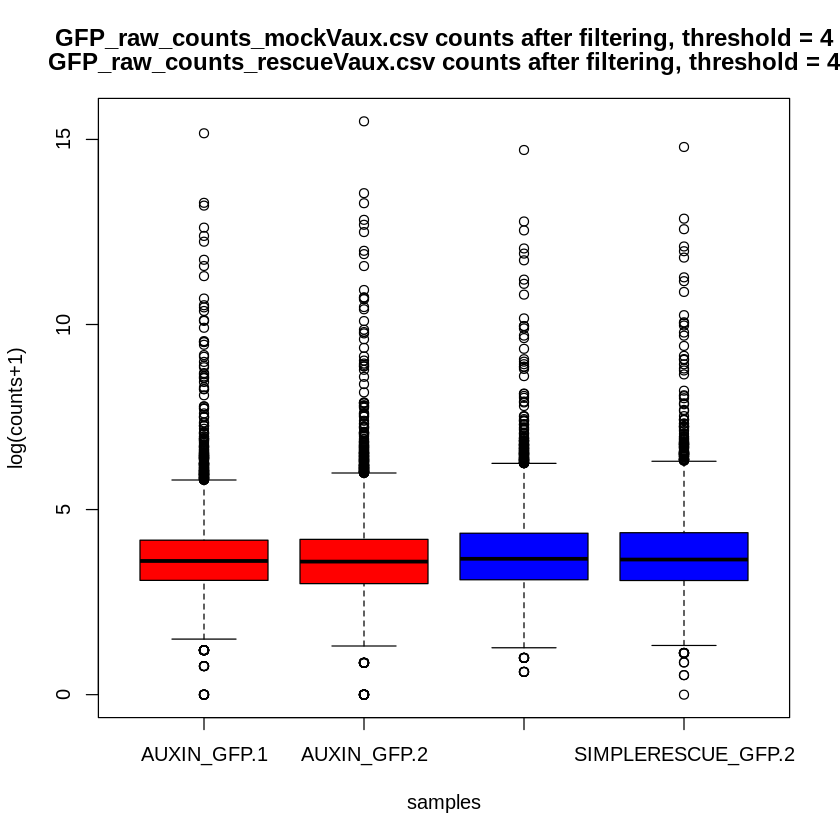

In [6]:
mydeseq(gfp_mtx,gfp_cld,gfp_spl,padjThreshold,l2fcThreshold)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



Auxin_K27.1 Auxin_K27.2  Mock_K27.1  Mock_K27.2 
  0.4055133   0.6308237   1.7169556   2.5695952 


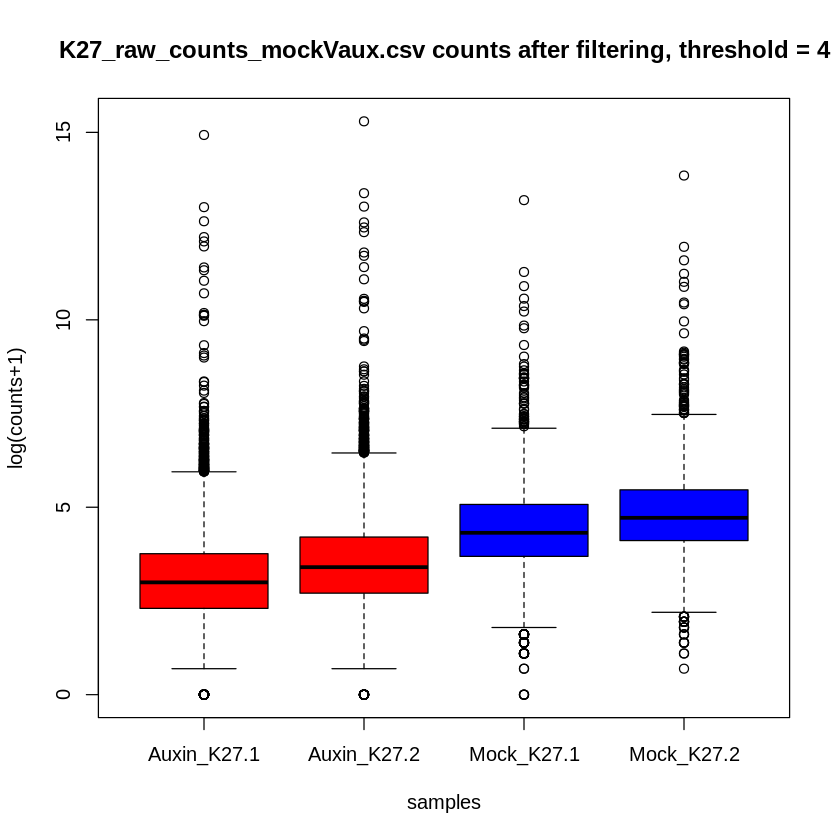

Warning message:
“Removed 918 rows containing missing values (`geom_point()`).”


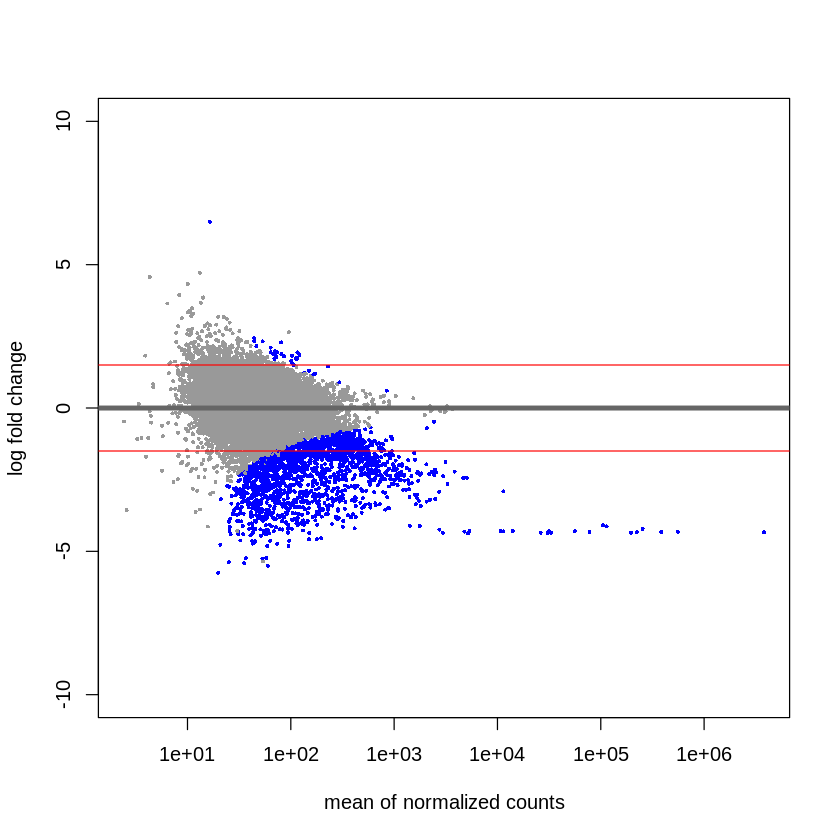

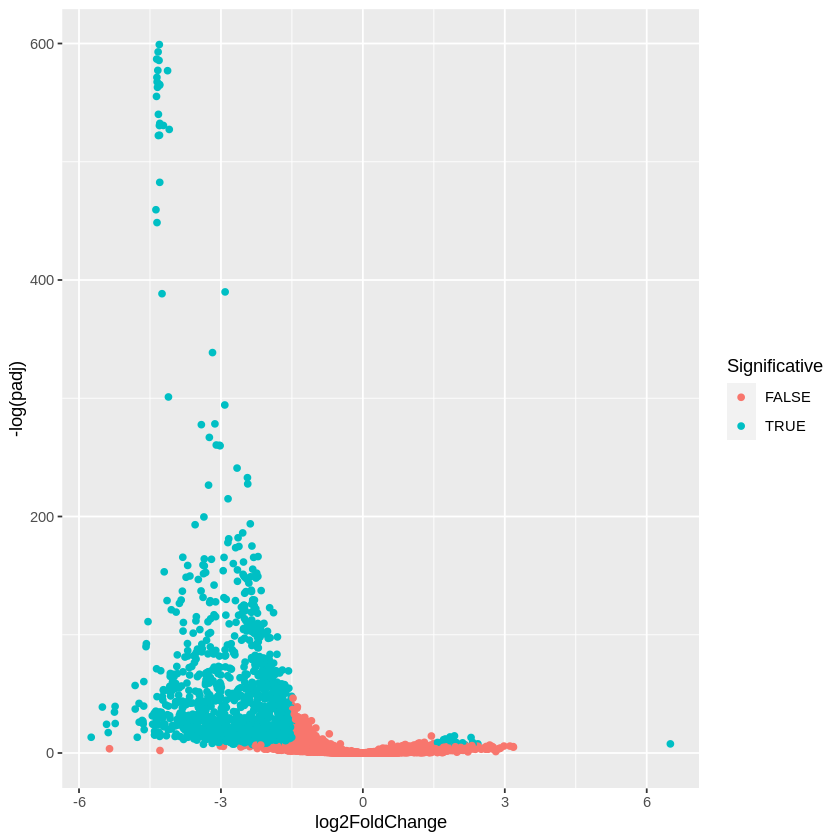

[1] "Significative increased signal: 26"
[1] "Significative decreased signal: 1316"
[1] "log2(FoldChange) threshold: +/-1.5"
[1] "Adjusted P-value threshold: 0.001"


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



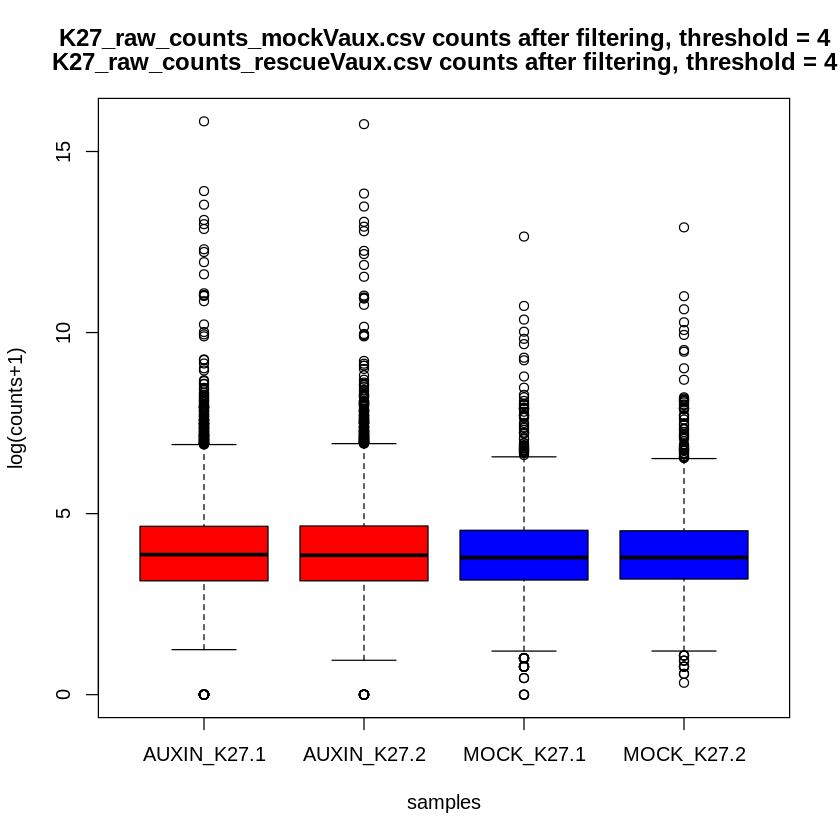

       Auxin_K27.1        Auxin_K27.2 SimpleRescue_K27.1 SimpleRescue_K27.2 
         0.3902793          0.6133041          2.3084270          1.9125994 


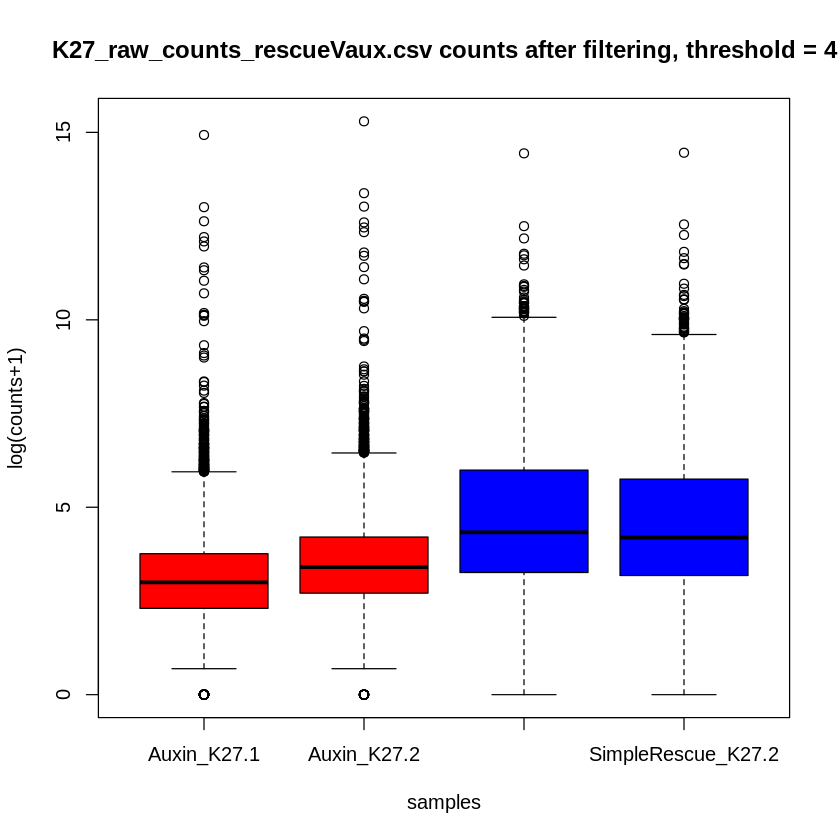

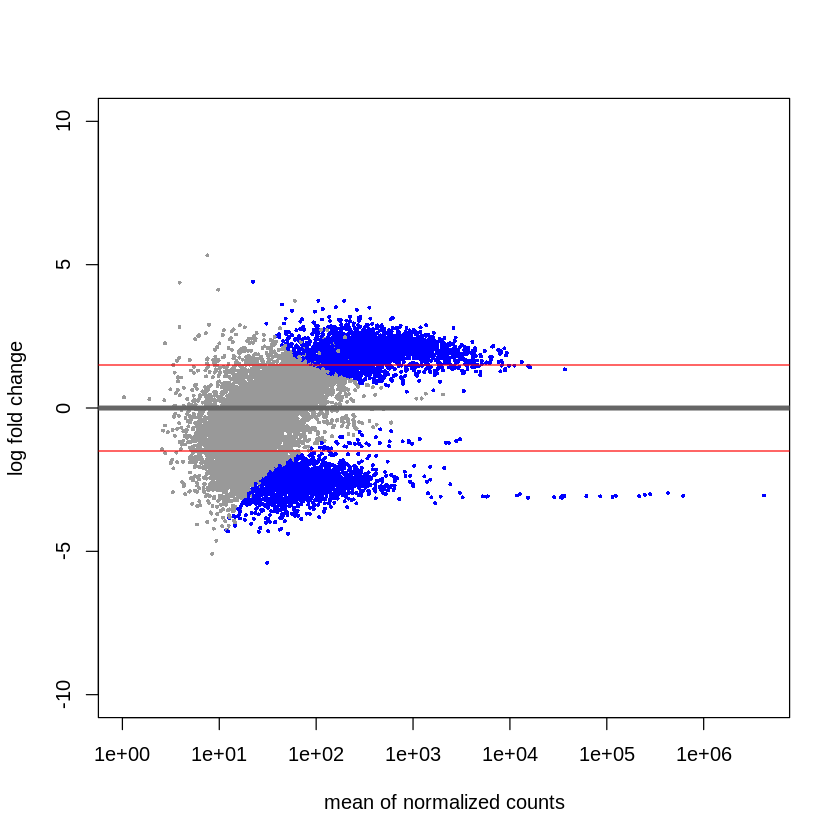

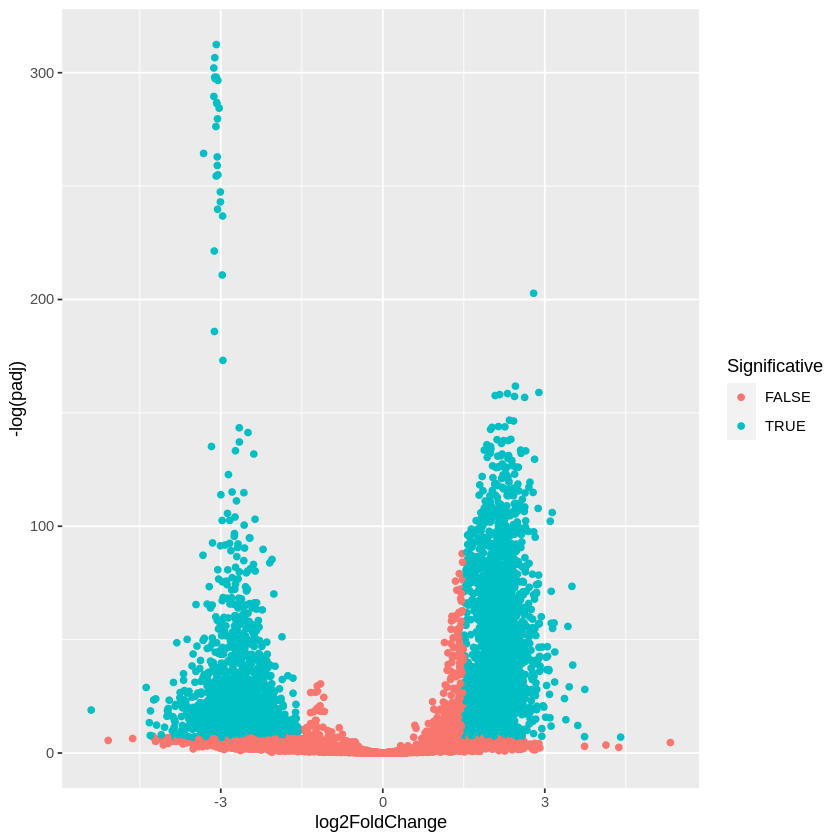

[1] "Significative increased signal: 2448"
[1] "Significative decreased signal: 1740"
[1] "log2(FoldChange) threshold: +/-1.5"
[1] "Adjusted P-value threshold: 0.001"


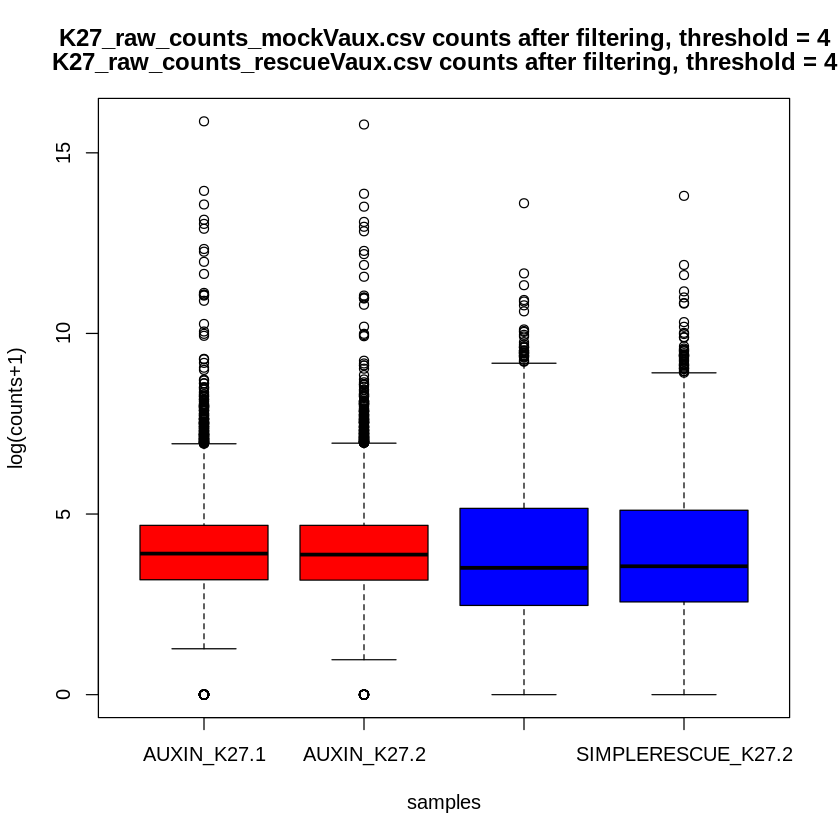

In [7]:
mydeseq(k27_mtx,k27_cld,k27_spl,padjThreshold,l2fcThreshold)

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



Auxin_UB.1 Auxin_UB.2  Mock_UB.1  Mock_UB.2 
 0.8648009  1.4761186  0.8433951  0.9723639 


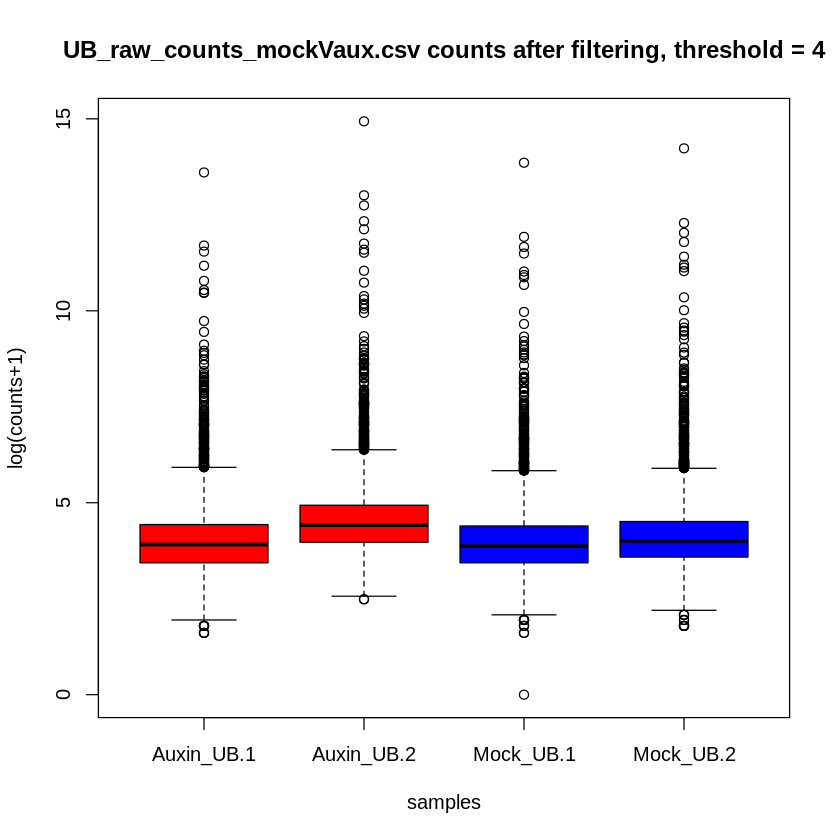

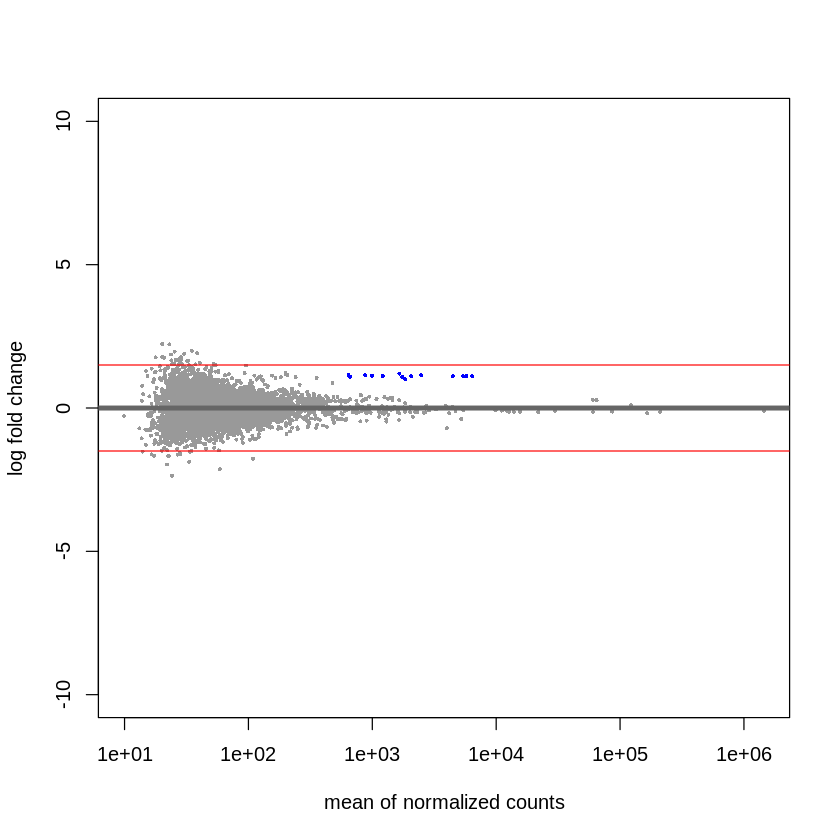

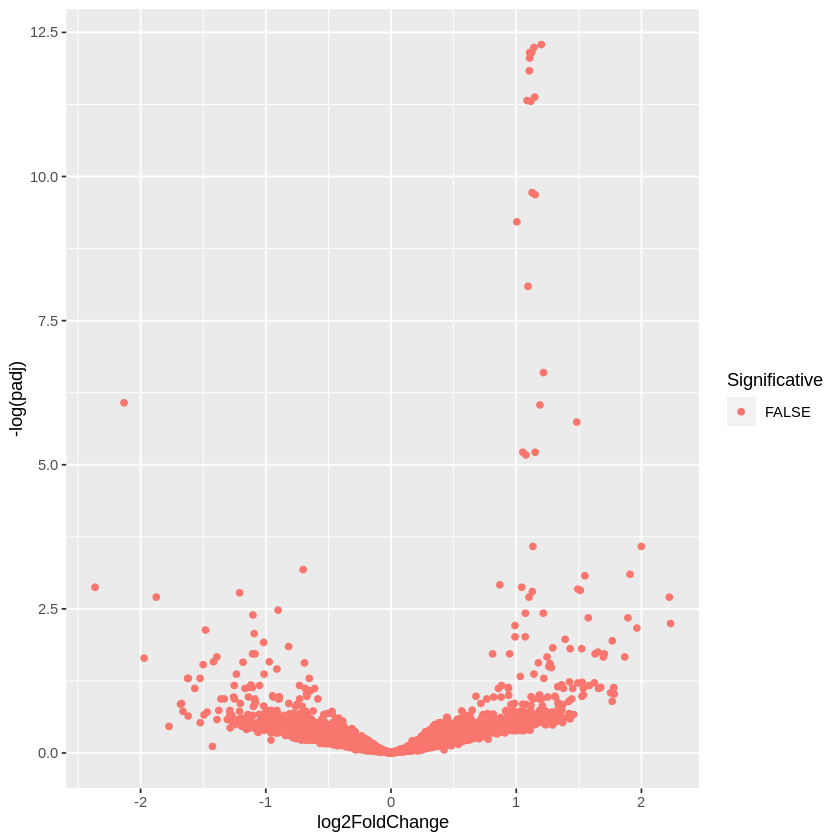

[1] "Significative increased signal: 0"
[1] "Significative decreased signal: 0"
[1] "log2(FoldChange) threshold: +/-1.5"
[1] "Adjusted P-value threshold: 0.001"


estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



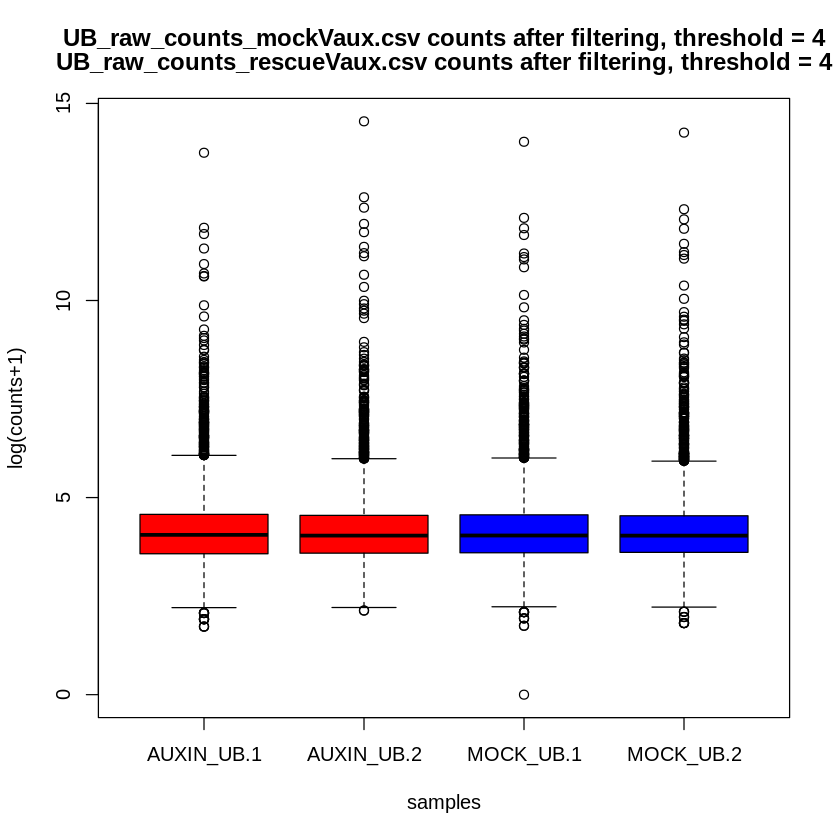

        Auxin_UB.1         Auxin_UB.2 RescateSimple_UB.1 RescateSimple_UB.2 
         0.9146478          1.5575437          0.7561804          0.9525548 


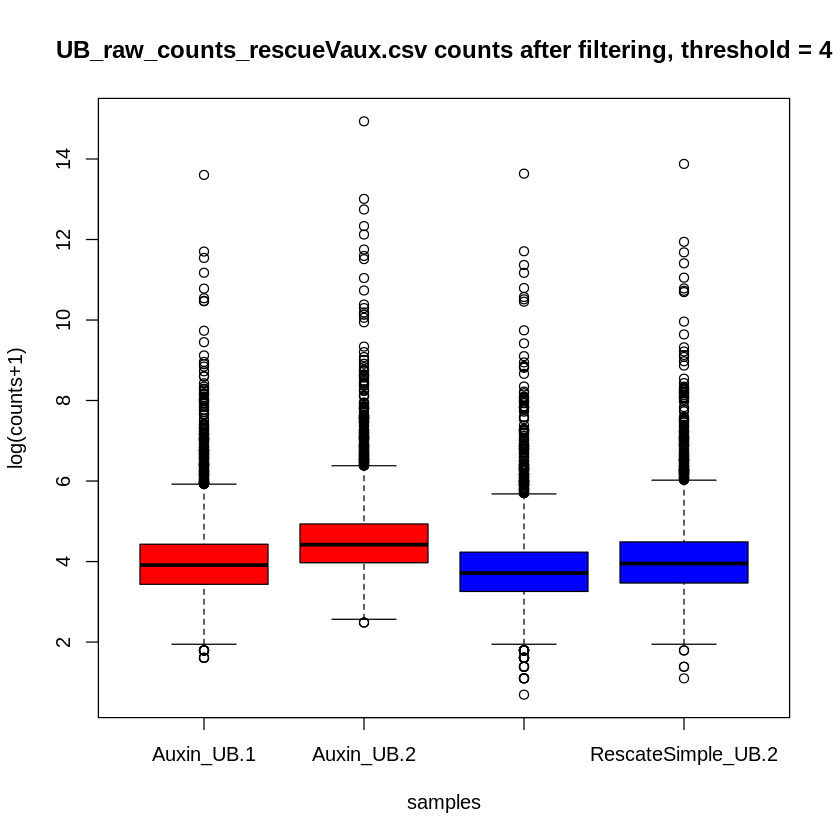

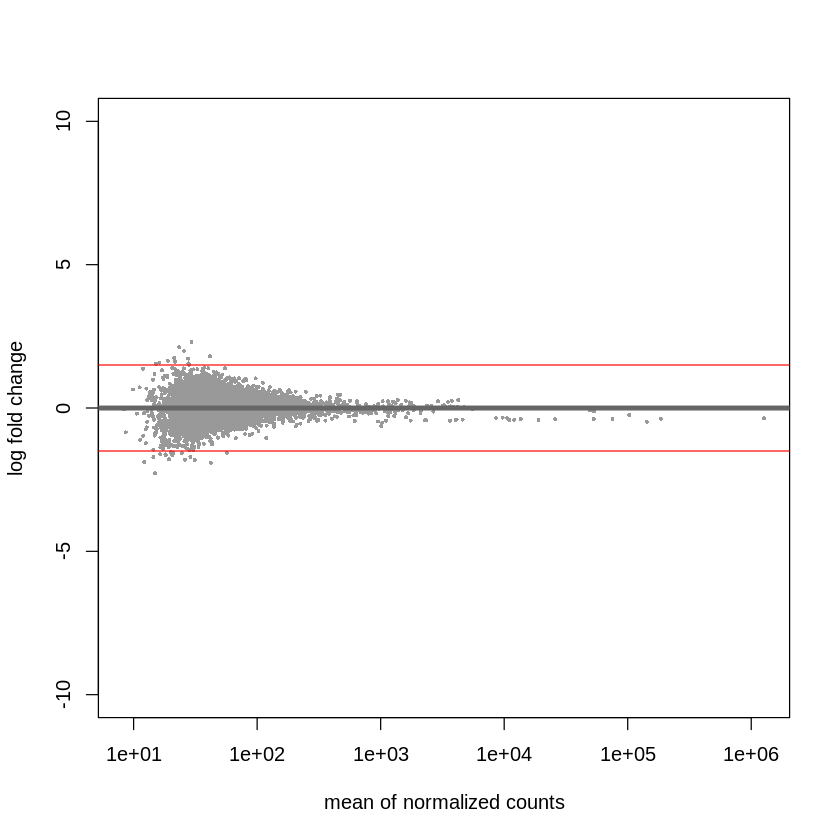

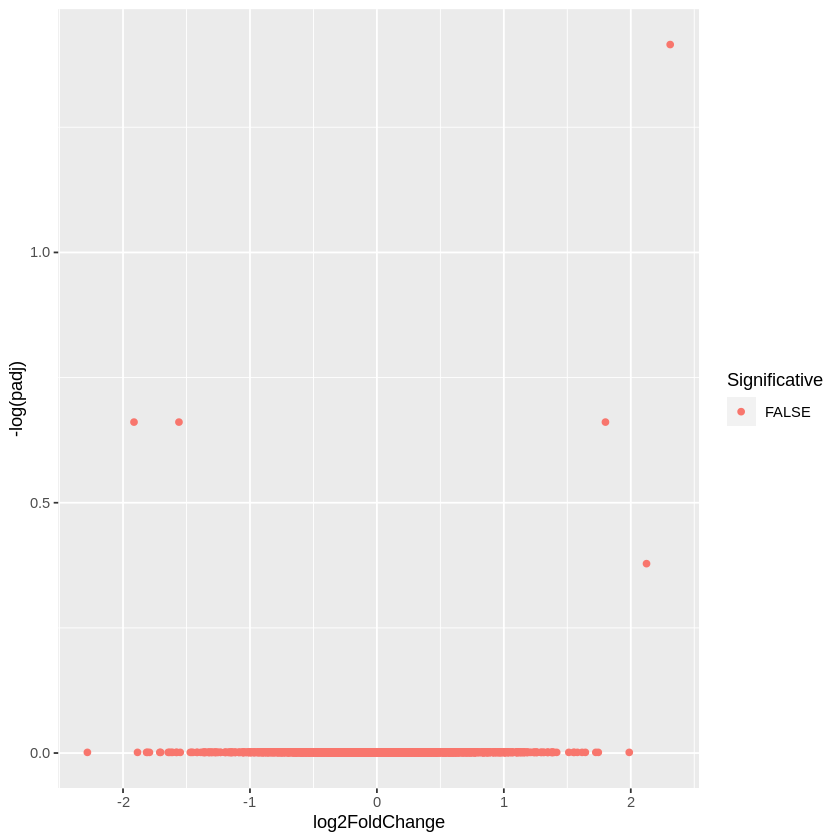

[1] "Significative increased signal: 0"
[1] "Significative decreased signal: 0"
[1] "log2(FoldChange) threshold: +/-1.5"
[1] "Adjusted P-value threshold: 0.001"


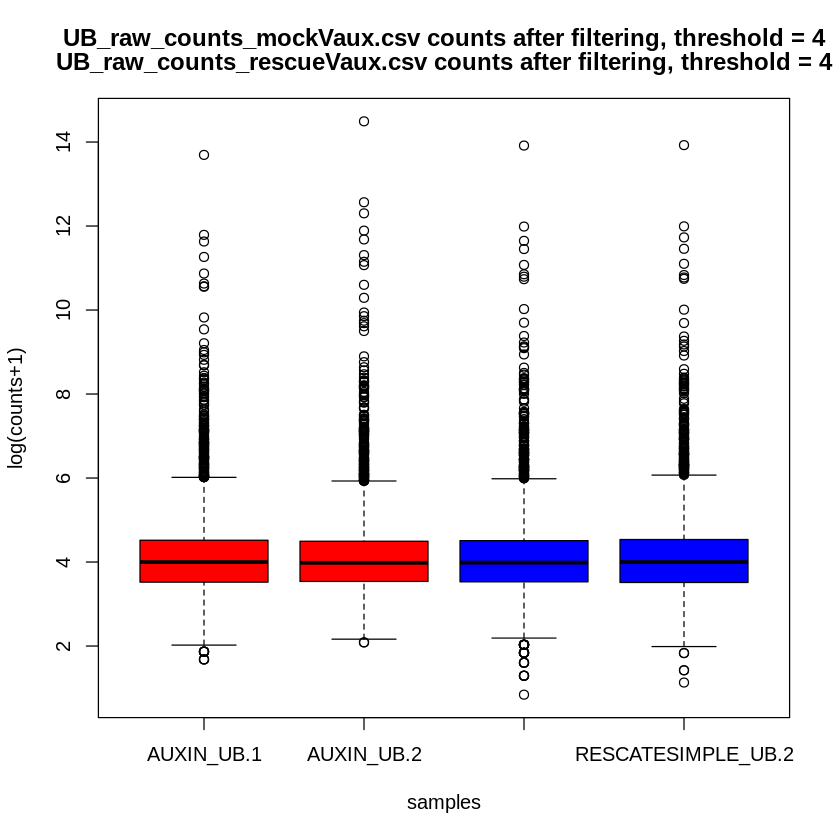

In [8]:
mydeseq(ub_mtx,ub_cld,ub_spl,padjThreshold,l2fcThreshold)